In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

from tsp_backend import polar_to_cartesian, plot_tsp_route, simmulated_annealing_tsp, constant_traffic_factor_func, nearest_neighbor_tsp, calculate_route_cost, make_distance_matrix, check_if_in_polygon



In [2]:
def traffic_factor_no_traffic(cost : float) -> float:
    return constant_traffic_factor_func(1.0, 0.0, cost)

def traffic_factor_with_traffic(cost : float) -> float:
    return constant_traffic_factor_func(10.0, 4.0, cost)

# Circle

In [3]:
N = 8
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes_circle_N_8 = polar_to_cartesian(R, phi)

Temperature: 0.1, Current Cost: 11.468892546624792
Current route: [0 2 3 5 7 6 1 4]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 6.122934917841436
Current route: [0 1 2 3 4 5 6 7]
num consec rejections: 22, num iter: 168
Temperature: 0.01, Current Cost: 6.122934917841436
Current route: [0 1 2 3 4 5 6 7]
num consec rejections: 24, num iter: 24
Temperature: 0.001, Current Cost: 6.122934917841436
Current route: [0 1 2 3 4 5 6 7]
num consec rejections: 21, num iter: 24


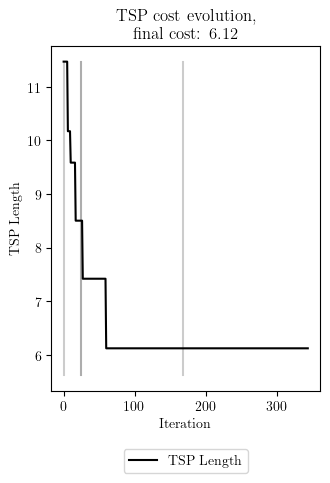

In [4]:
 

optimal_circle_N_8, optimal_cost_circle_N_8 = simmulated_annealing_tsp(
    nodes_circle_N_8, 
    traffic_factor=traffic_factor_no_traffic, 
    start_point_index=0, 
    rejection_threshold=[20,20,20,20], 
    max_iter_per_temperature=300,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_circle_N_8.pdf')

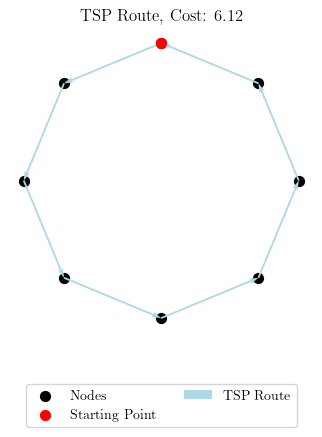

In [5]:
plot_tsp_route(nodes_circle_N_8, 
               optimal_circle_N_8, 
               output_path='plots/optimal_route_circle_N_8.pdf', 
               cost=optimal_cost_circle_N_8, 
               want_axis=False)

In [6]:
 

nearest_neighbor_circle_N_8 = nearest_neighbor_tsp(nodes_circle_N_8, start_point_index=0)

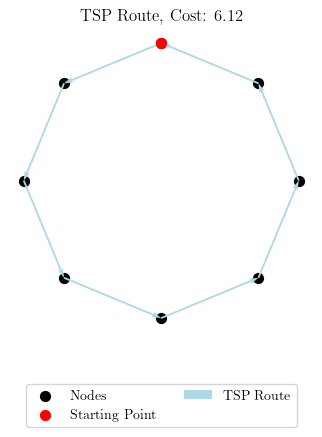

In [7]:
optimal_cost_nearest_neighbor_circle_N_8 = calculate_route_cost(
    nodes_circle_N_8, 
    nearest_neighbor_circle_N_8, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_circle_N_8),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_circle_N_8, 
               nearest_neighbor_circle_N_8, 
               output_path='plots/nearest_neighbor_circle_N_8.pdf', 
               cost=optimal_cost_nearest_neighbor_circle_N_8,
               want_axis=False)

# Large Circle


In [8]:
N = 100
R = 1
phi = np.array([2 * np.pi * i / N + np.pi / 2 for i in range(0,N)])

nodes_circle_N_100 = polar_to_cartesian(R, phi)

Temperature: 0.1, Current Cost: 137.67564346169704
Current route: [ 0 33 13 65 36 87 28 19 79 15 68 43 95 26 73  9 41 89 85  2 46  5 67 58
 51 10 34 37 77 27 30 78 24 20 17 39  6 53 80 59 94 90 66 48  4 55 18 32
 76 75 14 97 40 42 96 83 61 50 91 57 25 86 31 47 82  1 69 81 49 71 23 74
 64 88 12 52 29 22  7 98 84 45 93 92 38  8  3 72 21 54 44 62 99 11 16 60
 63 35 70 56]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 37.91472725642621
Current route: [ 0  2 96 83 70 71 68 74 72 77 80 79 76 75 81 88 85 86 87 97  6  4 10 16
  5 11 18 17 20 29 15 13 26 22 21 19 23 27 30 25 33 24 49 31 35 37 39 32
 36 38 28 60 63 41 42 45 46 48 47 40 44 43 50 34 57 59 55 51 56 69 78 73
 64 52 53 58 54 66 67 62 65 61 82 84 90 98 89  8 12 14  9  7 95 91 94 93
 92 99  1  3]
num consec rejections: 29, num iter: 1583
Temperature: 0.01, Current Cost: 10.79637712743645
Current route: [ 0 99 96 97 98 95 91 93 94 92 90 89 88 86 87 85 84 81 82 83 80 77 78 79
 76 75 72 71 70 74 73 69 68 66 67 64 

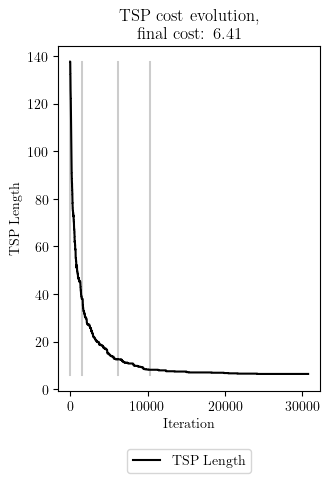

In [9]:
 

optimal_circle_N_100, optimal_cost_circle_N_100 = simmulated_annealing_tsp(
    nodes_circle_N_100, 
    traffic_factor=traffic_factor_no_traffic, 
    start_point_index=0, 
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_circle_N_100.pdf')

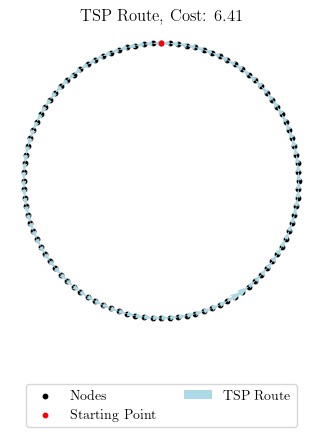

In [10]:
plot_tsp_route(nodes_circle_N_100, 
               optimal_circle_N_100, 
               output_path='plots/optimal_route_circle_N_100.pdf', 
               cost=optimal_cost_circle_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=False)

In [11]:
 

nearest_neighbor_circle_N_100 = nearest_neighbor_tsp(nodes_circle_N_100, start_point_index=0)

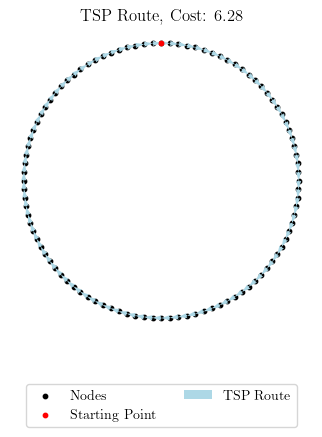

In [12]:
optimal_cost_nearest_neighbor_circle_N_100 = calculate_route_cost(
    nodes_circle_N_100, 
    nearest_neighbor_circle_N_100, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_circle_N_100),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_circle_N_100, 
               nearest_neighbor_circle_N_100, 
               output_path='plots/nearest_neighbor_circle_N_100.pdf',
               cost=optimal_cost_nearest_neighbor_circle_N_100,
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=False)

# Two seperated squares of equal lattice nodes

In [13]:
N = 10

x_coordinates_1 = np.linspace(-1.1, -0.1, N)
y_coordinates_1 = np.linspace(0.1 , 1.1, N)

X, Y = np.meshgrid(x_coordinates_1, y_coordinates_1)
coordinates_1 = np.column_stack([X.flatten(), Y.flatten()])

x_coordinates_2 = np.linspace(0.1, 1.1, N)
y_coordinates_2 = np.linspace(-1.1 , -0.1, N)

X, Y = np.meshgrid(x_coordinates_2, y_coordinates_2)
coordinates_2 = np.column_stack([X.flatten(), Y.flatten()])

nodes_two_squares = np.append(coordinates_1, coordinates_2, axis=0)

Temperature: 0.1, Current Cost: 232.05748233083176
Current route: [  0   4  42  61  25 191 160 111 169 156   1 178  27  81  74 167  79 152
 183  85  90 148  63   7 161 189 150  44 117 139  24  13 134  70 103  94
  26  66  95 126 136 137  15 128  22  71 105  33  14  39  73  65 114  20
  92 170 151  60  45 129 112 113  75  50  30 173  99  48 181  40 155  67
  34 118 168  88 116  83 127 190 163 177 164  91 140  97   3 171  23 106
   2 199 174 157 101 166  77  47  11  54 108 120  28 188   8  84 115  58
  18 187 146 135  87 179 130  31 107  55  46 154 125 147  82  29  37 175
 197 158 194 119  10  76  98  64 198 159 132 141   5 143  36  35   9  93
 149 185 180  43  59 124 133  57 162  19 145 123  68  16 186 102  78 121
 100 176  52  38  86  62  17 104 195 196 109  32 153 122 110 192 144  49
 165 131  72 182  21  53  56  80  12  41   6 172  51 193  96  69 142 184
  89 138]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 58.355847273450635
Current route: [  0   1  21  22

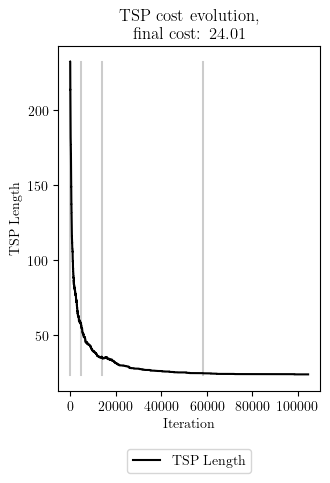

In [14]:
 

optimal_two_square_N_10, optimal_two_square_cost_N_10 = simmulated_annealing_tsp(nodes_two_squares, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_two_squares_N_10.pdf')

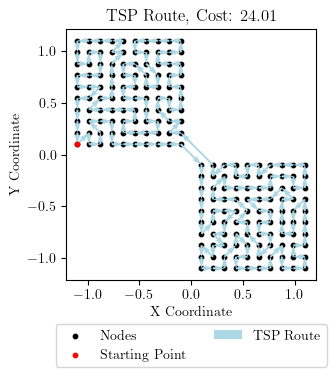

In [15]:
plot_tsp_route(nodes_two_squares, 
               optimal_two_square_N_10, 
               output_path='plots/optimal_route_two_square_N_10.pdf', 
               cost=optimal_two_square_cost_N_10, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

In [16]:
 

nearest_neighbor_two_square_N_10 = nearest_neighbor_tsp(nodes_two_squares, start_point_index=0)

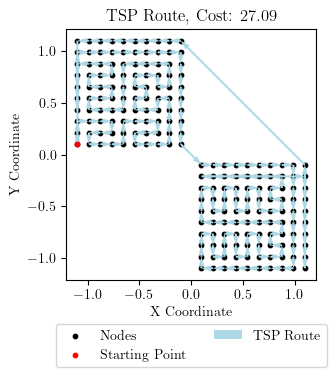

In [17]:
optimal_cost_nearest_neighbor_two_square_N_10 = calculate_route_cost(
    nodes_two_squares, 
    nearest_neighbor_two_square_N_10, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_two_squares),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_two_squares, 
               nearest_neighbor_two_square_N_10,
               output_path='plots/nearest_neighbor_two_square_N_10.pdf',
               cost=optimal_cost_nearest_neighbor_two_square_N_10,
               arrow_width=0.008, 
               node_dot_size=10,
               want_axis=True)


# Random points in a unit square

In [18]:
N = 100
x = np.random.rand(N)
y = np.random.rand(N)
nodes_random_N_100 = np.column_stack([x, y])

Temperature: 0.1, Current Cost: 47.63928570479916
Current route: [ 0 26 35 74 80 94 41 85 30 38 81 78 54 25 33 73 95 62 99 48 86 67 70 69
 59 72 84 43 22 17 93 23 55 20 90 61 57 60 46 77  4 97 34 27 42 91 83  6
 89 32 71 15 18 11 29 50 68 24 28 66 45 36  9 47 88 56  2 13 53 14 98 63
 76 16  8  3 87  7 79 12 31 58  1 65 37 44 51 75 40 92 10 49 19 52 39 96
 64  5 21 82]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 19.658206326207193
Current route: [ 0 84 15 26 50 78 41 74 42 64 58 80 70  3 19 90  8  9 48  5 98 68 49 82
 31 32 45 87  7 18 67 39 40 35  4 36 95 57 59 56 38 47 94  6 55 22 63 52
 24 93  1 99 66 37 85 13 34 23 65 10 14 12 11 69 86 60 44  2 91 53 88 73
 27 20 21 25 16 33 89 54 97 28 71 81 96 51 30 75 77 46 76 79 61 29 17 62
 72 43 92 83]
num consec rejections: 35, num iter: 2829
Reached maximum number of iterations for temperature 0.05. :(
Temperature: 0.01, Current Cost: 10.624982949034761
Current route: [ 0 69 11 84 10 14 46 20 40 74 42 96 12 51 26 6

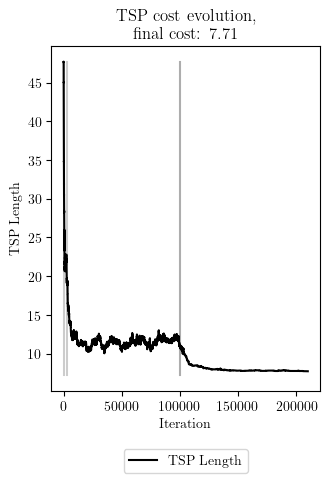

In [19]:
 

optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100.pdf')

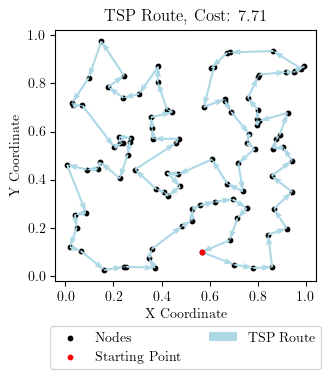

In [20]:
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100, 
               output_path='plots/optimal_route_random_square_N_100.pdf', 
               cost=optimal_random_square_cost_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

In [21]:
 

nearest_neighbor_random_square_N_100 = nearest_neighbor_tsp(nodes_random_N_100, start_point_index=0)

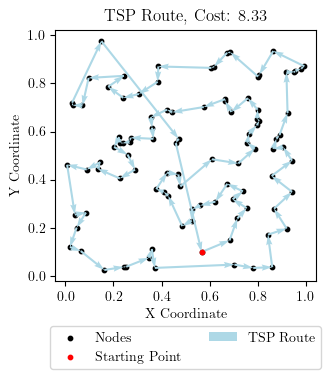

In [22]:
optimal_cost_nearest_neighbor_random_square_N_100 = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_random_N_100, 
               nearest_neighbor_random_square_N_100,
               output_path='plots/nearest_neighbor_random_square_N_100.pdf',
               cost=optimal_cost_nearest_neighbor_random_square_N_100,
               arrow_width=0.008,
               node_dot_size=10,
               want_axis=True)

Temperature: 0.1, Current Cost: 51.07457730172864
Current route: [ 0 77 14 87 81 20 19 36 82  4  1 93 83 73 11 29 91 95 55 71 54 42 21 10
 51 94 15 45 44 30 37 13 60 34 62 90  6 96 38 98 25  3 61  7 70 39 85 58
 80 89  9 97 53 12 41 86  5  8 69 75 59 78 74 28 57 16 27 23 92 64 84 49
 63 22 67 43 72 50 24 68 40 35 17 88 48 31 99 33 52 46 26  2 32 18 79 47
 66 76 65 56]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 19.650899279488833
Current route: [ 0 51 10 79 83 29 17 19 31 57 25 54 16 52  4 33 78 77 35 23 36 63 75 22
 65 71 64  5 74 59 91 38  3 90  6 32 87 45 95 98 21 58 12 39 50 67 18 81
 26 84 15 86 11 96 76 61 62  8 27  7 88 60 44 46 69 30 42 73 68  9 41 40
 92 43 72  2 80 53 37 66 99 85 34  1 89 55 13 28 24 97 93 49 82 94 47 70
 56 48 20 14]
num consec rejections: 22, num iter: 11383
Temperature: 0.01, Current Cost: 10.000625955337794
Current route: [ 0 79 92 83 76 43 61 72  2 29 62 17 91  3 90 19 88  8 73 80 64 74 58  9
 42 41 96 60 12 46 44 69 14 10 51 2

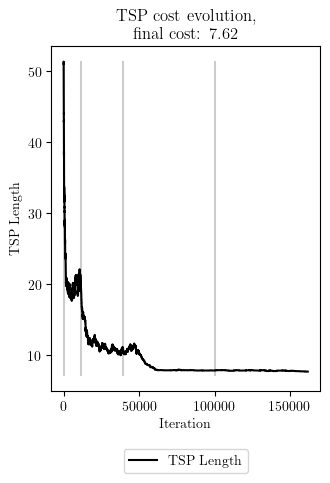

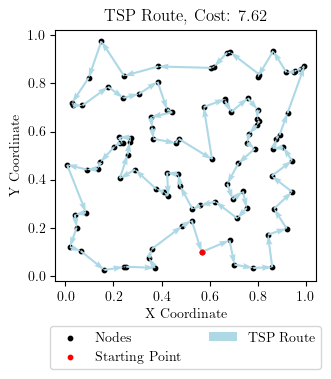

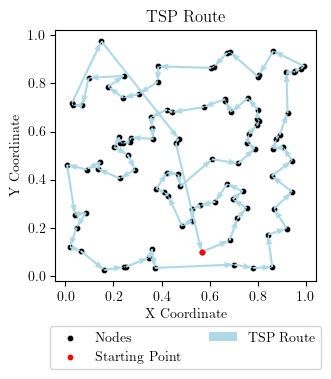

In [23]:
optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_no_traffic, 
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100, 
               output_path='plots/optimal_route_random_square_N_100_2.pdf', 
               cost=optimal_random_square_cost_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

nearest_neighbor_random_square_N_100 = nearest_neighbor_tsp(nodes_random_N_100, start_point_index=0)
optimal_cost_nearest_neighbor_random_square_N_100 = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    np.array([], dtype=int), 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_no_traffic,
    0.0)
plot_tsp_route(nodes_random_N_100, 
               nearest_neighbor_random_square_N_100,
               output_path='plots/nearest_neighbor_random_square_N_100_2.pdf',
               arrow_width=0.008,
               node_dot_size=10,
               want_axis=True)

In [24]:
traffic_polygon = np.array([[0.2, 0.8], [0.8, 0.8], [0.8, 0.2], [0.2, 0.2]])

# With Traffic
### ambigious start point

Temperature: 0.1, Current Cost: 107.8614763569634
Current route: [ 0 75 45 74 98 93 27 16 83 56 89 26 65 61 10 78 40 67 23 80 52 64 19 90
 77  2 82 71 58  8 84 28 33 14 91 59 72 51 96 34 68 39 20  9 49 76 42 36
 50 87 86 53  6 11 32 18 99 66 81 38 43 57 73 15  4 88 37 30 95 13 12 55
  3 29 63 47 60 31 22 17 41  1  7 97 94 62  5 35 69 44 24 70 92 25 48 21
 54 79 85 46]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 29.09106281209295
Current route: [ 0 83 42 80 58 30 51  9 12 19 21 47 76 96 60 61  6  4 37 85 77 22 55 92
 88 38 45 71 63 67 41 43 73 82 57 70 53 27 59 31 48 89 36 81 10 18 20 65
 34 39 75 40 32  5 95 66 99 50  1 97 52 93 94 56  7 24 16 49  8 91  3 90
  2 29 17 68 98 87 33 25 28 35 13 54 23 78 86 46 26 69 15 74 64 62 72 79
 84 44 11 14]
num consec rejections: 20, num iter: 1675
Temperature: 0.01, Current Cost: 13.194759604348848
Current route: [ 0 26 11 69 51 12 96 44 74 42 58 41 48 21  5 95  6 98 27 53 59 19 70 56
 94 47 88 73  9 40 20 14 10 77 71 78 

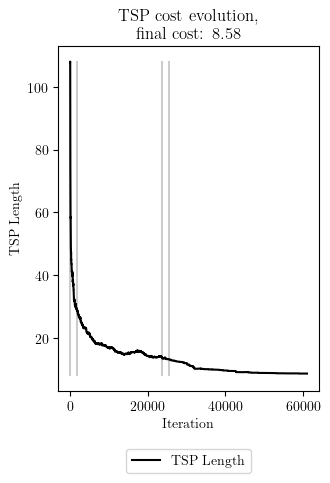

In [25]:
 

optimal_random_square_N_100, optimal_random_square_cost_N_100 = simmulated_annealing_tsp(nodes_random_N_100, 
                                                                                  traffic_factor=traffic_factor_with_traffic, 
                                                                                  traffic_start_time=4,
                                                                                  traffic_polygon=traffic_polygon,
                                                                                  start_point_index=0, 
                                                                                  max_iter_per_temperature=1e5,
                                                                                  plot_cost=True, 
                                                                                  plot_cost_out_path='plots/convergence_random_squares_N_100_with_traffic.pdf')

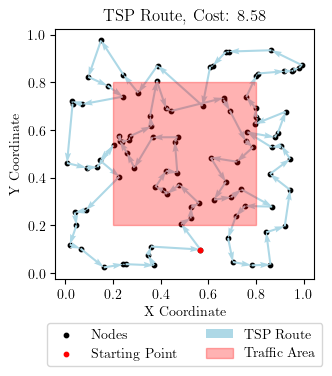

In [26]:
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100, 
               traffic_polygon=traffic_polygon,
               output_path='plots/optimal_route_random_square_N_100_with_traffic.pdf', 
               cost=optimal_random_square_cost_N_100, 
               arrow_width=0.008, 
               node_dot_size=10, 
               want_axis=True)

In [27]:
random_nodes_in_traffic_polygon = np.array([i for i in range(N) if check_if_in_polygon(nodes_random_N_100[i], traffic_polygon)])
random_nodes_outside_traffic_polygon = np.array([i for i in range(N) if not check_if_in_polygon(nodes_random_N_100[i], traffic_polygon)])

optimal_cost_nearest_neighbor_random_square_N_100_traffic = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100, 
    random_nodes_in_traffic_polygon, 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
print(f'Optimal cost nearest neighbor random square N 100 with traffic: {optimal_cost_nearest_neighbor_random_square_N_100_traffic}')

Optimal cost nearest neighbor random square N 100 with traffic: 9.125238932708504


### Start point outside of traffic

Temperature: 0.1, Current Cost: 119.26750834134634
Current route: [ 0 63 19 82 43 47 89 17 11 57 64 53 29 22 60 69  6 70 42 94 56 34 62 51
 13 77 45  9 98 25  4 46  1 16 12 14 21 36 84 58  8 75 85 27 95 41 20  5
  3 91 39 80 55 54 90 44 31 52 96 66 50 71 15 35 86 97 26 73 10 24 88 33
 72 76 78 59 87 92 81 65 37 99 67 30 32 61 74 28 38 49 79  7 83 68 23 18
 93 48 40  2]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 28.080536921019636
Current route: [ 0 46 40 64 91 68 80 88  6  5 58 51 27 53 57  7 87 95 96 26 15 61 17 12
 83 20 84 69 86 77 63 93 98 19 59 38 70 94 49 82 28 37 13 55 18 33  4 34
 35 23 21 32 52 97 39 36 99 71 79 62  9 92 76 43 44 81 11 42 30 67 10 50
 65 22 54 24 25 45 73 29  8 90  2 41 56 74 75 78  1 66 16 85 89 14  3 48
 31 47 72 60]
num consec rejections: 43, num iter: 1733
Temperature: 0.01, Current Cost: 12.587750228415452
Current route: [ 0 12 96 40 46 20 51  9 58 64 41 73 53 94 59 47  8 88 27 68  6  7 32 95
  5 48 98 21 52 16 25  4 33 35 23 5

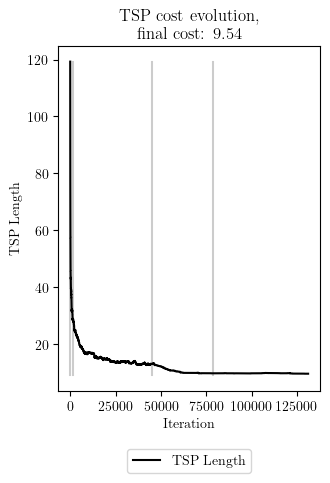

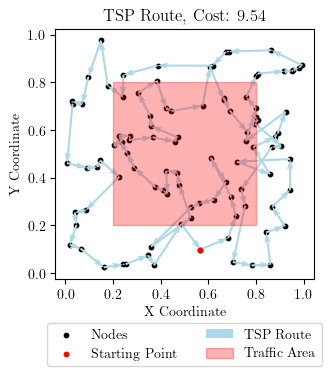

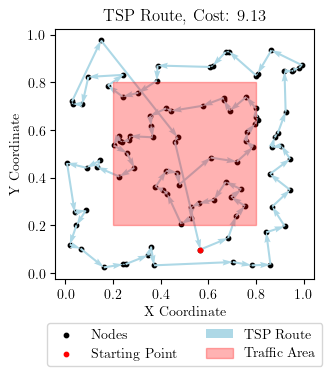

Optimal cost nearest neighbor random square N 100 with fixed start: 9.125238932708504


In [28]:
# fix the start point to the first index of a node outside of the traffic polygon

start_index = random_nodes_outside_traffic_polygon[0]
# simulate annealing with fixed start point outside of traffic polygon
optimal_random_square_N_100_fixed_start, optimal_random_square_cost_N_100_fixed_start = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=4,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic.pdf')

plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

# nearest neighbor with fixed start point outside of traffic polygon
nearest_neighbor_random_square_N_100_fixed_start = nearest_neighbor_tsp(
    nodes_random_N_100, 
    start_point_index=start_index
)
optimal_cost_nearest_neighbor_random_square_N_100_fixed_start = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100_fixed_start, 
    random_nodes_in_traffic_polygon, 
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
# plot the route of the nearest neighbor with fixed start point outside of traffic polygon
plot_tsp_route(nodes_random_N_100, 
               nearest_neighbor_random_square_N_100_fixed_start,
               traffic_polygon=traffic_polygon,
               output_path='plots/nearest_neighbor_random_square_N_100_fixed_start_outside_with_traffic.pdf',
               cost=optimal_cost_nearest_neighbor_random_square_N_100_fixed_start,
               arrow_width=0.008,
               node_dot_size=10,
               want_axis=True)
print(f'Optimal cost nearest neighbor random square N 100 with fixed start: {optimal_cost_nearest_neighbor_random_square_N_100_fixed_start}')

### Fixed start point inside of traffic area

Temperature: 0.1, Current Cost: 113.65325104796771
Current route: [ 5 45 69 82  2 88 42 59 20 73 53 36 13 89 12 74 66 70 71  6 22 44 62 23
 43 41  8 65 15 21 80 54 16 52 64 17 93 63 56 86  7 96 97 25 18 58 47 38
 39 19 77 95 31 60 98 11 61 85 91 57 81  0 79 46 99 24 26 14 35 33 68 28
 90 75 10 76 87  1 48 32 92 84 83 50 27 72 51 29  4 94 78 49 40 55  9 67
 30  3 37 34]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 35.745294303131715
Current route: [ 5  6 14 74 36 55 20 59 12 73 42 53 98 90 68  7  2  9 66  1 34 37 65 25
 32 51  0 92 43 96 83 58 29 79 47 94 17 72  3 61 76 88 56 27 82 31 33 87
 57 19 26 71 85 78 50 41 86 35 23 48 84 64 49 95 11 46 10 15 77 39 99 21
 28 22 60 62 40 30  4 54 81 75 63 16 97 13 52 93 67 80 89 69 38 70  8 91
 44 18 24 45]
num consec rejections: 22, num iter: 666
Temperature: 0.01, Current Cost: 12.153257956053137
Current route: [ 5 95 45  7 48  6 98 68  8 90 59 94 47 53 27 88 73 64 74 58 41 21 40  9
 42 96 12 51 14 20 30 86 67 71 78 36

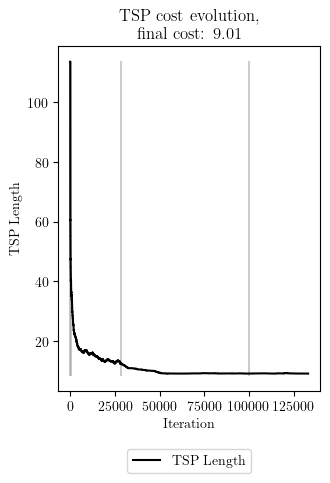

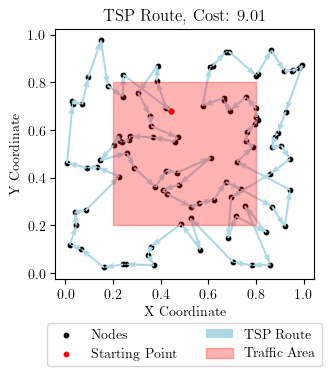

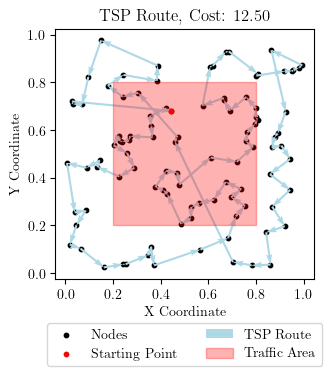

Optimal cost nearest neighbor random square N 100 with fixed start inside: 12.49575354517033


In [29]:
# start point fixed inside of the traffic polygon
start_index_inside = random_nodes_in_traffic_polygon[0]
optimal_random_square_N_100_fixed_start_inside, optimal_random_square_cost_N_100_fixed_start_inside = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=4,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_inside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_inside_with_traffic.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_inside, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_inside_with_traffic.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_inside,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

nearest_neighbor_random_square_N_100_fixed_start_inside = nearest_neighbor_tsp(
    nodes_random_N_100, 
    start_point_index=start_index_inside
)
optimal_cost_nearest_neighbor_random_square_N_100_fixed_start_inside = calculate_route_cost(
    nodes_random_N_100, 
    nearest_neighbor_random_square_N_100_fixed_start_inside,
    random_nodes_in_traffic_polygon,
    make_distance_matrix(nodes_random_N_100),
    traffic_factor_with_traffic,
    4.0)
plot_tsp_route(nodes_random_N_100,
                nearest_neighbor_random_square_N_100_fixed_start_inside,
                traffic_polygon=traffic_polygon,
                output_path='plots/nearest_neighbor_random_square_N_100_fixed_start_inside_with_traffic.pdf',
                cost=optimal_cost_nearest_neighbor_random_square_N_100_fixed_start_inside,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)
print(f'Optimal cost nearest neighbor random square N 100 with fixed start inside: {optimal_cost_nearest_neighbor_random_square_N_100_fixed_start_inside}')

Temperature: 0.1, Current Cost: 109.52420363351519
Current route: [ 0 34 39  3 71 82 69 53 47  6  5 36 11 91 90 13 88 42 59 97 52  7 79 30
 93 67 25 35 18 17 65 61 92 24 60 99  4 14 76 78 19 72 51 74 87  1 70 41
 10 94 96 33 63 64 43 83 58 54 85 56  9 49 62  2 40 12 32 73 29 38 16 80
 81 77 66  8 55 21 84 50 89 28 37 68 26 46 75 44 45 27 98 95 23 15 20 31
 57 48 22 86]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 28.57670613605685
Current route: [ 0 68 72 29 91 47 56 94 70  7 32  5 87 27 63 55 78 50 40 22 77  1 37 23
 36 28 99 34 95 76 62 21 48 13 52 79 41  9 84 69 15 74 11 46 26 81 60 44
 92 10 86 64 58 43 80 17 73  2  8  3 90 59 19 57 31 98 49 82 24 33 85 66
 54 89  6 93 25 97  4 16 65 51 30 14 75 35 39 20 67 71 18 42 45 53 38 88
 61 83 96 12]
num consec rejections: 39, num iter: 3312
Reached maximum number of iterations for temperature 0.05. :(
Temperature: 0.01, Current Cost: 20.47605227357521
Current route: [ 0 51 65 77 50 71 86 14 67 20 75 40 18 22 36  4

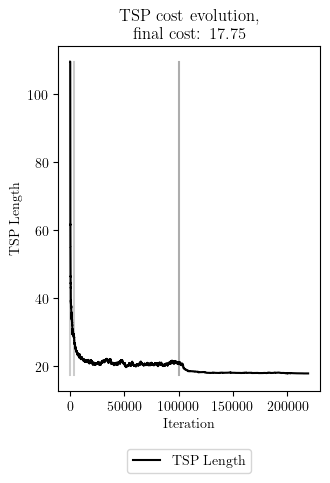

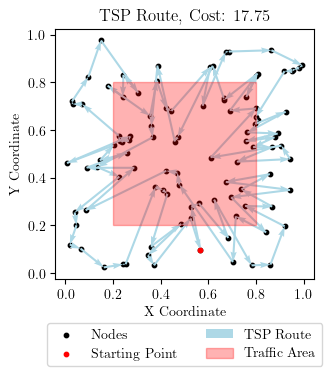

Temperature: 0.1, Current Cost: 95.09512658950591
Current route: [ 0 32 62 59 75 64 41 85 57 99 67 37  8 28 86 71 68  5 92 55 26 74 45  9
 39 56 44 25 83  6 72 60 66 80 12 94 53 27 42 93 95 98 78 69  4  2 40 17
 14 31 81 11 21 16 30 13  3 29 23  7 54 97 79 36 46 96 19 70 51 65 18 49
 10 35 38 48 76 87 88 63 61 20 90 33 22 77 89 58 15  1 50 47 84 34 73 24
 82 91 52 43]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 24.85343320503249
Current route: [ 0 44 96 74 20 48 21  5 28 36 51  9 41 98 73  6 59 33 16 25 66 13 50 77
 65 75 12 81 69 67 78  4 39 99 85 37 34 55 23 35 87 88 76 72 62 61 29 27
 19  8 82  7 31 32 97  1 95 24 54 15 10 79 58 64 26 92 53 43 42 18 71 89
 22 63 68  2 17 56 38  3 47 90 94 91 80 70 49 57 45 93 52 83 60 11 46 84
 86 14 30 40]
num consec rejections: 20, num iter: 2907
Temperature: 0.01, Current Cost: 15.44734144210736
Current route: [ 0 83 44 96 51 20 46 41  9 74 58 21 98 94  8 27 59 73 48  6 25 33  1 13
 37 28 66 54 16 23 36 77 18 71 78 63 3

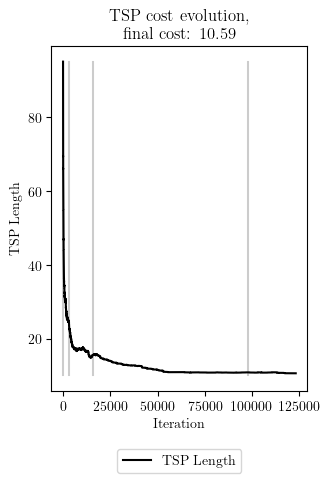

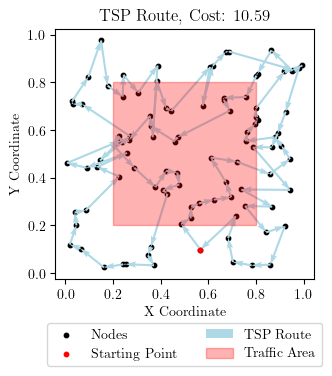

Temperature: 0.1, Current Cost: 105.93931383435229
Current route: [ 0 19 15 48 31 84 98 37 22 92 93 97 75 47 94 86 54 65 52 46 21 99 89 83
 85 80  8  1  5 28 10 11 74 71  7 95 55 88 73  2 53 25 24 29 68 43 67 44
 62 39 69 12 66 77 35 18 33 78 34 40 82  4 13 38 91 14  6 60 79 58 41 50
 72 42 96 51 59 76 26 23 61 87 63  9 64 36 16 81 17 56 90 27 45 30 70 57
 49 32 20  3]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 42.13539901182791
Current route: [ 0 73 30 36 68 92 12 41 45  9 60 10 67 95 87 82 31  2 98 88 91 76 69 71
 24  4 13 16 37 85 52 33 32 59 27  6 17  8 19 20 14 39 34 48 11 74 28  5
 53 94 61 78 89 99 22 57 81 35  1 66 47 38  7 15 65 40 18 64 63 97 93 23
 54 75 55 90 29 56 25  3 80 70 21 50 51 49 42 84 77 26 44 62 83 46 86 72
 79 58 43 96]
num consec rejections: 29, num iter: 481
Temperature: 0.01, Current Cost: 9.855463690742807
Current route: [ 0 60 12 96 44 51 67 30 86 15 81 11 84 26 69 46 10 14 20 40 16 33 25 66
  1 39 78 23 35 36 22 63 65 75 77 18 5

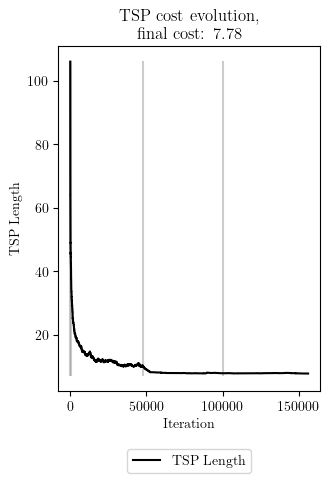

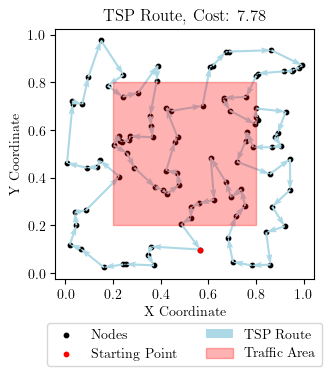

In [30]:
# simulated annealing with fixed start point ouside of traffic polygon for three different start times
start_index_outside = random_nodes_outside_traffic_polygon[0]

def traffic_factor_with_traffic_instant_start(cost : float) -> float:
    return constant_traffic_factor_func(10.0, 0.0, cost)

def traffic_factor_with_traffic_start_8(cost : float) -> float:
    return constant_traffic_factor_func(10.0, 8.0, cost)

# instand start
optimal_random_square_N_100_fixed_start_outside_start_0, optimal_random_square_cost_N_100_fixed_start_outside_start_0 = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic_instant_start, 
    traffic_start_time=0,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_outside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic_start_time_0.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_outside_start_0, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic_start_time_0.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_outside_start_0,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

# start time 4
optimal_random_square_N_100_fixed_start_outside_start_4, optimal_random_square_cost_N_100_fixed_start_outside_start_4 = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic, 
    traffic_start_time=4,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_outside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic_start_time_4.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_outside_start_4, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic_start_time_4.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_outside_start_4,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)
    
# start time 8
optimal_random_square_N_100_fixed_start_outside_start_8, optimal_random_square_cost_N_100_fixed_start_outside_start_8 = simmulated_annealing_tsp(
    nodes_random_N_100, 
    traffic_factor=traffic_factor_with_traffic_start_8, 
    traffic_start_time=8,
    traffic_polygon=traffic_polygon,
    start_point_index=start_index_outside, 
    max_iter_per_temperature=1e5,
    plot_cost=True, 
    plot_cost_out_path='plots/convergence_random_squares_N_100_fixed_start_outside_with_traffic_start_time_8.pdf')
plot_tsp_route(nodes_random_N_100, 
               optimal_random_square_N_100_fixed_start_outside_start_8, 
                traffic_polygon=traffic_polygon,
                output_path='plots/optimal_route_random_square_N_100_fixed_start_outside_with_traffic_start_time_8.pdf',
                cost=optimal_random_square_cost_N_100_fixed_start_outside_start_8,
                arrow_width=0.008,
                node_dot_size=10,
                want_axis=True)

# Altstadt Kneipen


In [31]:
# read distance matrix for Altstadt Kneipen
altstadt_distance_df = pd.read_csv('Distance_matrix_Altstadt_Kneipen(Tabelle1).csv', delimiter=';')
altstadt_distance_matrix = altstadt_distance_df.to_numpy()[:, 1:].astype(float)  # convert to numpy array and skip the first column which contains the names of the bars

altstadt_cost_matrix = altstadt_distance_matrix / (3.0 / 3.6)  # assuming 3 km/h walking speed, so cost is distance in km divided by 5 km/h to get time in hours
print(altstadt_cost_matrix.dtype)

float64


In [32]:
alcohol_effect_start = 60 * 10  # we assume 10 minutes till the effect starts

def drunk_traffic_factor(cost: float) -> float:
    # linearly increasing traffic factor, 
    # assuming half the walking velocity for every promille of alcohol in the blood, starting with a factor of 1.0 at 0 promille and increasing by 1.0 for every additional promille
    return constant_traffic_factor_func(1.0 + 0.1 * (cost - alcohol_effect_start), alcohol_effect_start, cost)


Temperature: 0.1, Current Cost: 85554376582243.23
Current route: [ 5  4 13  8 12  3 10  1 11  9  6  7  0  2]
num consec rejections: 0, num iter: 0
Temperature: 0.05, Current Cost: 27858.68275200006
Current route: [ 9 10  8 11  7 12  0  6  5  3  4  1 13  2]
num consec rejections: 202, num iter: 846
Temperature: 0.01, Current Cost: 27858.68275200006
Current route: [ 9 10  8 11  7 12  0  6  5  3  4  1 13  2]
num consec rejections: 406, num iter: 406
Temperature: 0.001, Current Cost: 27858.68275200006
Current route: [ 9 10  8 11  7 12  0  6  5  3  4  1 13  2]
num consec rejections: 602, num iter: 602


FileNotFoundError: [Errno 2] No such file or directory: 'bar_plots/convergence_bars_with_drunk_traffic_0.pdf'

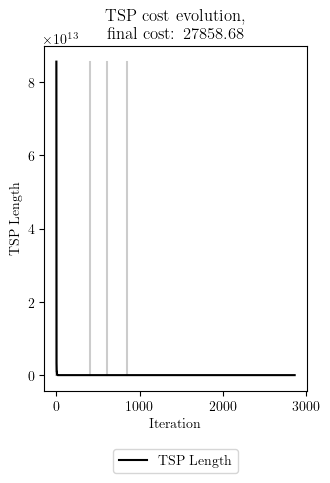

In [33]:

# 14 bars in the oldtown nodes
nodes_bars = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [0.5, 0.5], [0.2, 0.8], [0.8, 0.2], [0.3, 0.3], [0.7, 0.7], [0.4, 0.6], [0.6, 0.4], [0.1, 0.9], [0.9, 0.1], [0.5, 0.75]])

routes = []
route_costs = []

for i in range(100):
    drunk_optimal_route, drunk_route_cost = simmulated_annealing_tsp(nodes_bars, 
                            pre_determined_distance_matrix=altstadt_cost_matrix,
                            traffic_factor=drunk_traffic_factor, 
                            traffic_start_time=alcohol_effect_start, 
                            rejection_threshold=[200, 400, 600, 1000],
                            traffic_polygon=np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 1.0], [1.0, 0.0]]),
                            plot_cost=True, 
                            plot_cost_out_path=f'bar_plots/convergence_bars_with_drunk_traffic_{i}.pdf')

    routes.append(drunk_optimal_route)
    route_costs.append(drunk_route_cost)

minimal_cost_index = np.argmin(route_costs)
drunk_optimal_route = routes[minimal_cost_index]

#print("Optimal route with drunk traffic factor:", altstadt_distance_df[0, drunk_optimal_route])
print(f"Optimal route (cost: {route_costs[minimal_cost_index]:.2f} seconds) with drunk traffic factor:")
for drunk_node in drunk_optimal_route:
    print(f"{altstadt_distance_df.columns[drunk_node + 1]}")
